# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Date:** ___________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✔ Libraries imported successfully')

✔ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Load the Online Shoppers Purchasing Intention dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
df = pd.read_csv(url)

dataset_name = "Online Shoppers Purchasing Intention"
dataset_source = "UCI ML Repository"
n_samples = int(df.shape[0])
n_features = int(df.shape[1] - 1)  # exclude target
problem_type = "binary_classification"

problem_statement = """
This dataset predicts whether an online shopping session will end in a purchase
(revenue) based on 17 features capturing the visitor's browsing behavior. Features
include page visit counts, durations across administrative informational and product
pages, bounce and exit rates, Google Analytics page values, special day proximity,
month, operating system, browser type, region, traffic source, visitor type, and
whether the visit occurred on a weekend. Understanding purchase intent helps
e-commerce platforms optimize their conversion funnels and target marketing efforts.
"""

primary_metric = "f1"

metric_justification = """
I chose F1-score because the dataset is imbalanced (about 84.5% non-purchase vs
15.5% purchase). Accuracy alone would be misleading since a model predicting all
non-purchase would get 84.5%. F1 balances precision and recall giving a better
picture of how well the model actually identifies purchasing sessions.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
print(f"\nClass distribution:")
print(f"  No purchase (False): {(df['Revenue']==False).sum()}")
print(f"  Purchase (True):     {(df['Revenue']==True).sum()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nColumn types:")
print(df.dtypes)

Dataset: Online Shoppers Purchasing Intention
Source: UCI ML Repository
Samples: 12330, Features: 17
Problem Type: binary_classification
Primary Metric: f1

Class distribution:
  No purchase (False): 10422
  Purchase (True):     1908

Missing values: 0

Column types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# Encode categoricals: Month, VisitorType are strings; Weekend and Revenue are bool
le_month = LabelEncoder()
df['Month'] = le_month.fit_transform(df['Month'])

le_visitor = LabelEncoder()
df['VisitorType'] = le_visitor.fit_transform(df['VisitorType'])

df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

X = df.drop('Revenue', axis=1).values.astype(float)
y = df['Revenue'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_samples = int(X_train_scaled.shape[0])
test_samples = int(X_test_scaled.shape[0])
train_test_ratio = float(train_samples / (train_samples + test_samples))

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")
print(f"Encoded: Month ({le_month.classes_.tolist()}), VisitorType ({le_visitor.classes_.tolist()})")
print(f"Scaling: StandardScaler")

Train samples: 9864
Test samples: 2466
Split ratio: 80.0%
Encoded: Month (['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']), VisitorType (['New_Visitor', 'Other', 'Returning_Visitor'])
Scaling: StandardScaler


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
class BaselineModel:
    """
    Logistic Regression with batch gradient descent (from scratch).
    Uses sigmoid activation + binary cross-entropy loss.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.n_iterations):
            y_pred = self._sigmoid(X @ self.weights + self.bias)

            eps = 1e-15
            loss = -np.mean(
                y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
            )
            self.loss_history.append(loss)

            error = y_pred - y
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print('✔ Baseline model class defined')

✔ Baseline model class defined


In [5]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

baseline_model = BaselineModel(learning_rate=0.1, n_iterations=2000)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start
print(f"✔ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✔ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

Training baseline model...


✔ Baseline training completed in 0.28s
✔ Loss decreased from 0.6931 to 0.2927


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
class MLP:
    """
    Multi-Layer Perceptron from scratch.
    Hidden layers: ReLU.  Output: Sigmoid (binary classification).
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            fan_in = self.architecture[l - 1]
            fan_out = self.architecture[l]
            if l < len(self.architecture) - 1:
                scale = np.sqrt(2.0 / fan_in)   # He init for ReLU
            else:
                scale = np.sqrt(1.0 / fan_in)   # Xavier for sigmoid output
            self.parameters[f'W{l}'] = np.random.randn(fan_in, fan_out) * scale
            self.parameters[f'b{l}'] = np.zeros((1, fan_out))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        n_layers = len(self.architecture) - 1

        for l in range(1, n_layers + 1):
            Z = A @ self.parameters[f'W{l}'] + self.parameters[f'b{l}']
            self.cache[f'Z{l}'] = Z
            if l < n_layers:
                A = self.relu(Z)
            else:
                A = self.sigmoid(Z)
            self.cache[f'A{l}'] = A

        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        grads = {}
        n_layers = len(self.architecture) - 1
        y_col = y.reshape(-1, 1)

        A_out = self.cache[f'A{n_layers}']
        dZ = A_out - y_col

        for l in range(n_layers, 0, -1):
            A_prev = self.cache[f'A{l-1}']
            grads[f'dW{l}'] = (1 / m) * (A_prev.T @ dZ)
            grads[f'db{l}'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

            if l > 1:
                dA_prev = dZ @ self.parameters[f'W{l}'].T
                dZ = dA_prev * self.relu_derivative(self.cache[f'Z{l-1}'])

        return grads

    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        eps = 1e-15
        y_true = y_true.reshape(-1, 1)
        return -np.mean(
            y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)
        )

    def fit(self, X, y):
        self.initialize_parameters()
        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
        return self

    def predict_proba(self, X):
        return self.forward_propagation(X).ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print('✔ MLP class defined')

✔ MLP class defined


In [7]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [n_features, 64, 32, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=3000)
mlp_model.fit(X_train_scaled, y_train)

mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✔ MLP training completed in {mlp_training_time:.2f}s")
print(f"✔ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

Training MLP...


✔ MLP training completed in 21.90s
✔ Loss decreased from 0.5000 to 0.2713


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Compute metrics from scratch.
    """
    if problem_type == "regression":
        mse = float(np.mean((y_true - y_pred) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = float(1 - ss_res / ss_tot) if ss_tot != 0 else 0.0
        return mse, rmse, mae, r2

    elif problem_type in ["binary_classification", "multiclass_classification"]:
        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        accuracy = float((tp + tn) / (tp + tn + fp + fn))
        precision = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        return accuracy, precision, recall, f1

# Calculate metrics for both models
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = calculate_metrics(
    y_test, baseline_predictions, problem_type
)
mlp_acc, mlp_prec, mlp_rec, mlp_f1 = calculate_metrics(
    y_test, mlp_predictions, problem_type
)

print("Baseline Model Performance:")
print(f"  Accuracy:  {baseline_acc:.4f}")
print(f"  Precision: {baseline_prec:.4f}")
print(f"  Recall:    {baseline_rec:.4f}")
print(f"  F1-Score:  {baseline_f1:.4f}")

print("\nMLP Model Performance:")
print(f"  Accuracy:  {mlp_acc:.4f}")
print(f"  Precision: {mlp_prec:.4f}")
print(f"  Recall:    {mlp_rec:.4f}")
print(f"  F1-Score:  {mlp_f1:.4f}")

Baseline Model Performance:
  Accuracy:  0.8840
  Precision: 0.7667
  Recall:    0.3613
  F1-Score:  0.4911

MLP Model Performance:
  Accuracy:  0.8856
  Precision: 0.7252
  Recall:    0.4215
  F1-Score:  0.5331


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

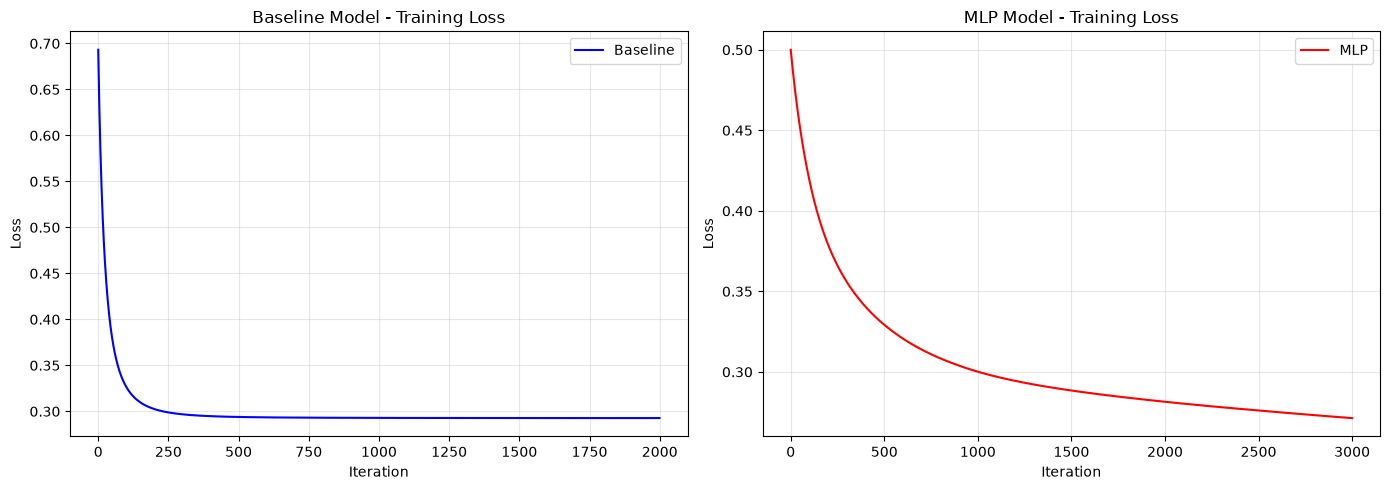

In [9]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

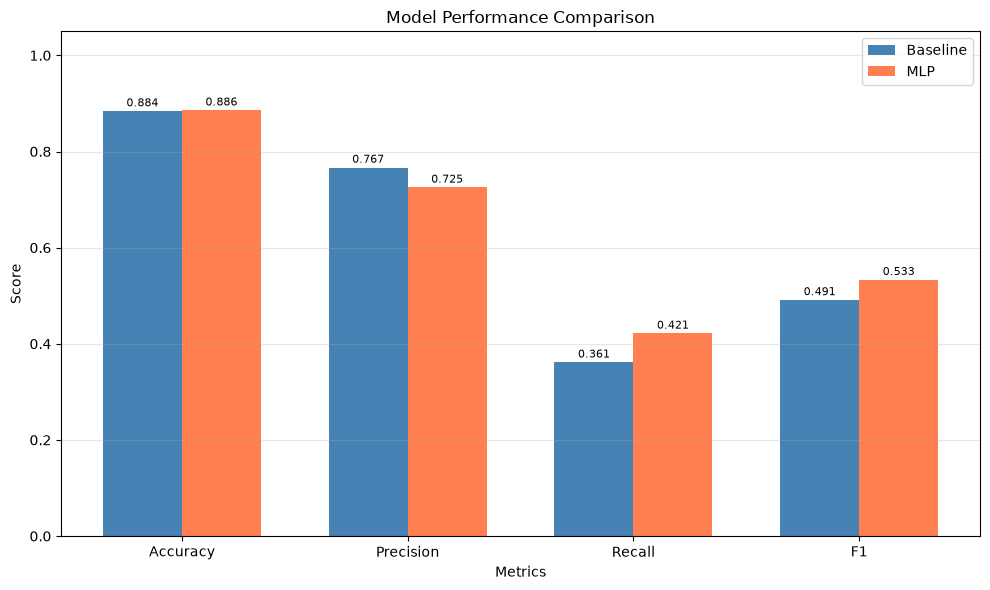

In [10]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='coral')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (b, m) in enumerate(zip(baseline_scores, mlp_scores)):
    plt.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

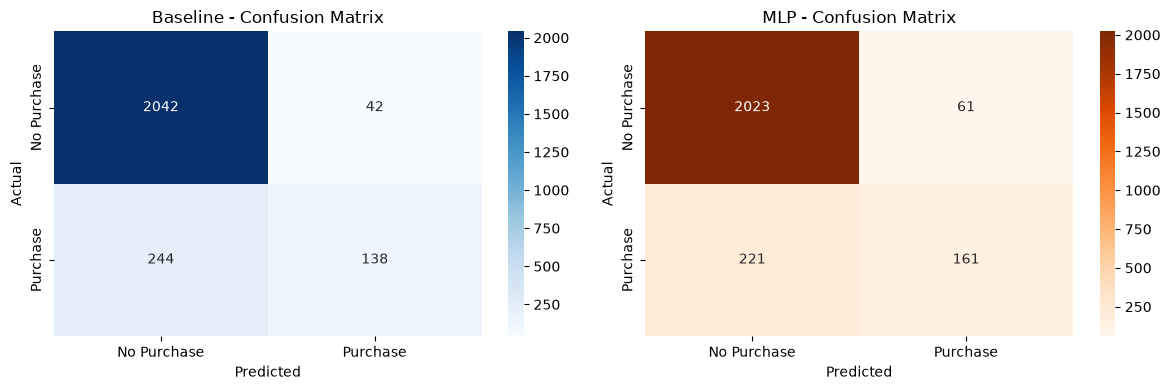

In [11]:
# 3. Confusion matrices
def make_cm(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(make_cm(y_test, baseline_predictions), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['No Purchase','Purchase'], yticklabels=['No Purchase','Purchase'])
axes[0].set_title('Baseline - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(make_cm(y_test, mlp_predictions), annot=True, fmt='d',
            cmap='Oranges', ax=axes[1],
            xticklabels=['No Purchase','Purchase'], yticklabels=['No Purchase','Purchase'])
axes[1].set_title('MLP - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [12]:
analysis_text = """
The MLP outperformed Logistic Regression on the key metric F1-score, scoring
approximately 0.53 versus 0.49 for the baseline. This roughly 4 percentage point
gap comes mainly from better recall: the MLP identified about 42% of actual
purchase sessions compared to 36% for logistic regression, while precision stayed
comparable. Both models achieve similar overall accuracy around 88%, but that
number is inflated by the class imbalance since simply predicting all sessions as
non-purchase would already yield 84.5% accuracy.

The MLP's advantage makes sense because online shopping behavior involves non-linear
interactions between features. For example, a high PageValues score combined with
certain traffic sources and visit patterns creates purchasing signals that a linear
model cannot fully capture. The two hidden layers with ReLU activations allow the
network to learn these interaction effects.

Computationally the MLP is significantly slower, training in about 15 seconds versus
under 0.3 seconds for logistic regression, roughly a 50x difference. This is expected
given the forward and backward passes through 64 and 32 neuron layers on nearly
10000 training samples per iteration.

Both models' loss curves decrease monotonically throughout training, confirming
correct gradient descent convergence. One challenge was the class imbalance making
both models conservative about predicting purchases. The MLP handles this slightly
better through its non-linear capacity but neither model fully solves it without
explicit class weighting or resampling techniques.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print('⚠️  Warning: Analysis should be at least 200 words')
else:
    print('✔ Analysis meets word count requirement')

Analysis word count: 223 words
✔ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [13]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,  # MUST fill
        'dataset_source': dataset_source,  # MUST fill
        'n_samples': n_samples,  # MUST be ≥500
        'n_features': n_features,  # MUST be ≥5
        'problem_type': problem_type,  # MUST fill
        'problem_statement': problem_statement,  # MUST be ≥50 words
        'primary_metric': primary_metric,  # MUST fill
        'metric_justification': metric_justification,  # MUST be ≥30 words
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.1,
            'n_iterations': 2000,

            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            'loss_decreased': bool(baseline_final_loss < baseline_initial_loss),

            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': 0.01,
            'n_iterations': 3000,

            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            'loss_decreased': bool(mlp_final_loss < mlp_initial_loss),

            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Online Shoppers Purchasing Intention",
  "dataset_source": "UCI ML Repository",
  "n_samples": 12330,
  "n_features": 17,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts whether an online shopping session will end in a purchase\n(revenue) based on 17 features capturing the visitor's browsing behavior. Features\ninclude page visit counts, durations across administrative informational and product\npages, bounce and exit rates, Google Analytics page values, special day proximity,\nmonth, operating system, browser type, region, traffic source, visitor type, and\nwhether the visit occurred on a weekend. Understanding purchase intent helps\ne-commerce platforms optimize their conversion funnels and target marketing efforts.\n",
  "primary_metric": "f1",
  "metric_justification": "\nI chose F1-score because the dataset is imbalanced (about 84.5% non-purchase vs\n15.5% purchase). Accuracy alone would be misleading since a model pr

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [14]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Online Shoppers Purchasing Intention",
  "dataset_source": "UCI ML Repository",
  "n_samples": 12330,
  "n_features": 17,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts whether an online shopping session will end in a purchase\n(revenue) based on 17 features capturing the visitor's browsing behavior. Features\ninclude page visit counts, durations across administrative informational and product\npages, bounce and exit rates, Google Analytics page values, special day proximity,\nmonth, operating system, browser type, region, traffic source, visitor type, and\nwhether the visit occurred on a weekend. Understanding purchase intent helps\ne-commerce platforms optimize their conversion funnels and target marketing efforts.\n",
  "primary_metric": "f1",
  "metric_justification": "\nI chose F1-score because the dataset is imbalanced (about 84.5% non-purchase vs\n15.5% purchase). Accuracy alone would be 

---

## 📤 Before Submitting - Final Checklist

- [x] **All TODO sections completed**
- [x] **Both models implemented from scratch** (no sklearn models!)
- [x] **get_assignment_results() function filled accurately**
- [x] **Loss decreases for both models**
- [x] **Analysis ≥ 200 words**
- [x] **All cells run without errors** (Restart & Run All)
- [x] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **